In [1]:
import sys, os

sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("helper"))

from plot_utils import (
    np,
    pd,
    plt,
    save_figure,
    load_file,
    read_config_from_csv,
    list_runs,
    FIGURE_SIZE_HALF,
    LINE_STYLE,
    GRID_STYLE,
    slate_teal,
    deep_red,
    warm_orange,
    plum,
    tan,
    sage,
    mid_grey,
    dark_grey,
)
from analysis import keep_changes

In [2]:
metrics_path = "../metrics"
FIG_DIR = "../figures/evaluation/scalability"
os.makedirs(FIG_DIR, exist_ok=True)

In [3]:
from glob import glob

base = os.path.join(metrics_path, "b1_convergence_n_sweep")
csvs = sorted(g for g in glob(f"{base}/conv_n_*_seed_*/2026-*.csv") if "__partial" not in g)

rows = []
for path in csvs:
    run_name = path.split("/")[-2]

    # Run folders look here like "conv_n_16_seed_3" or "..._full_mesh_fashion_mnist".
    dataset = "fashion_mnist" if run_name.endswith("_fashion_mnist") else "mnist"
    if dataset == "fashion_mnist":
        run_name = run_name[: -len("_fashion_mnist")]
    run_name = run_name.replace("_full_mesh", "")

    prefix, seed_str = run_name.split("_seed_")
    node_count = int(prefix.split("_")[-1])
    seed = int(seed_str)

    df = load_file(path)

    for field, label in (("aggregated_accuracy", "agg"), ("accuracy", "local")):
        acc = df[df.field == field][["timestamp", "node", "value"]].copy()
        acc["acc"] = pd.to_numeric(acc.value)

        for node, node_acc in acc.groupby("node"):
            node_acc = node_acc.sort_values("timestamp")

            # Keep only the rounds where accuracy changed, but always keep the
            # final reading, then drop any zero readings.
            changed = keep_changes(node_acc.acc)
            changed.iloc[-1] = True
            node_acc = node_acc[changed]
            node_acc = node_acc[node_acc.acc > 0]

            for round_number, value in enumerate(node_acc.acc.values, start=1):
                rows.append((dataset, node_count, seed, node, round_number, float(value), label))

df_conv_n = pd.DataFrame(rows, columns=["dataset", "n", "seed", "node", "round", "acc", "field"])

df_conv_n = df_conv_n[df_conv_n.n != 50].reset_index(drop=True)


def agg_by_n(df, field):
    sub = df[df.field == field]

    # First average across nodes within each (n, seed, round), then summarize
    # across seeds.
    per_seed_mean = sub.groupby(["n", "seed", "round"])["acc"].mean().reset_index()
    return (
        per_seed_mean.groupby(["n", "round"])["acc"]
        .agg(["mean", "min", "max", "count"])
        .reset_index()
    )


color_by_n = {6: slate_teal, 16: deep_red, 24: warm_orange, 32: plum, 40: sage, 50: tan, 64: dark_grey}
N_ROUND_XLIM = (0.5, 10.5)
N_ROUND_TICKS = list(range(1, 11))
N_YLIM = (0, 1.0)

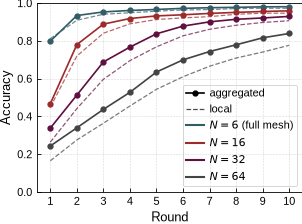

In [4]:
from matplotlib.lines import Line2D

seed_agg = agg_by_n(df_conv_n[df_conv_n.dataset == "mnist"], "agg")
seed_agg_local = agg_by_n(df_conv_n[df_conv_n.dataset == "mnist"], "local")


def render_overlap(seed_agg, seed_agg_local, out_name):
    fig, ax = plt.subplots(figsize=FIGURE_SIZE_HALF)

    node_counts = sorted(seed_agg.n.unique())
    for node_count in node_counts:
        color = color_by_n.get(node_count, mid_grey)

        agg_curve = seed_agg[seed_agg.n == node_count].sort_values("round")
        agg_curve = agg_curve[agg_curve["round"] <= N_ROUND_TICKS[-1]]

        local_curve = seed_agg_local[seed_agg_local.n == node_count].sort_values("round")
        local_curve = local_curve[local_curve["round"] <= N_ROUND_TICKS[-1]]

        ax.plot(agg_curve["round"], agg_curve["mean"], color=color, marker="o", markersize=3.5, **LINE_STYLE)
        ax.plot(local_curve["round"], local_curve["mean"], color=color, linestyle="--", linewidth=0.9, alpha=0.7)

    color_handles = [
        Line2D(
            [0],
            [0],
            color=color_by_n[node_count],
            linewidth=1.5,
            label=f"$N={node_count}$" + (" (full mesh)" if node_count == 6 else ""),
        )
        for node_count in node_counts
    ]
    style_handles = [
        Line2D([0], [0], color="black", linewidth=1.2, marker="o", markersize=3.5, label="aggregated"),
        Line2D([0], [0], color="black", linewidth=0.9, linestyle="--", alpha=0.7, label="local"),
    ]

    ax.legend(handles=style_handles + color_handles, loc="lower right", framealpha=0.9)

    ax.set_xlabel("Round")
    ax.set_ylabel("Accuracy")

    ax.grid(**GRID_STYLE)

    ax.set_xlim(*N_ROUND_XLIM)
    ax.set_xticks(N_ROUND_TICKS)
    ax.set_ylim(*N_YLIM)

    fig.tight_layout()
    save_figure(fig, f"{FIG_DIR}/{out_name}")
    plt.show()


render_overlap(seed_agg, seed_agg_local, "accuracy_overlap_by_n.pdf")

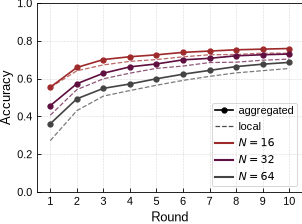

In [5]:
seed_agg_fashion = agg_by_n(df_conv_n[df_conv_n.dataset == "fashion_mnist"], "agg")
seed_agg_local_fashion = agg_by_n(df_conv_n[df_conv_n.dataset == "fashion_mnist"], "local")
render_overlap(seed_agg_fashion, seed_agg_local_fashion, "accuracy_overlap_by_n_fashion.pdf")